# Data 200 Final Project: NBA Player Performance, Roles, and Archetypes

## Project Goals

- Examine how NBA player statistics relate to scoring output and player efficiency.
- Build regression models to estimate `PTS` and `PER`, comparing interpretable and non-linear approaches.
- Classify players into broad position/role groups using their statistical profiles.
- Use clustering to explore player archetypes and compare them to traditional basketball roles.

## Data Description

Main files used in this notebook:
- `player_basic.csv`: basic player box-score statistics (e.g., `PTS`, `AST`, `TRB`, `FG`, `3P`, `MP`, `G`).
- `player_advanced.csv`: advanced player metrics (e.g., `PER`, `TS%`, `USG%`, `VORP`, `WS`, `BPM`).
- `nbateamdata.csv`: team-level statistics (referenced for project context).

The modeling workflow merges basic and advanced player data on `Player` and `Team` to combine scoring-volume measures with efficiency/value metrics.

Important data considerations:
- Aggregate rows such as `League Average` and multi-team aggregates (`2TM`) are handled before role modeling.
- Some percentage fields (e.g., `3P%`, `FT%`, `FG%`, `eFG%`, `TS%`) can be missing for players with low or zero attempts, so missing values are treated carefully rather than dropping large numbers of rows.

In [46]:
# Shared imports
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression, LassoCV
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    classification_report,
    confusion_matrix,
    silhouette_score,
)
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.cluster import AgglomerativeClustering, KMeans
from scipy.cluster.hierarchy import linkage, dendrogram
from matplotlib.colors import ListedColormap

sns.set_theme(style="whitegrid")

In [47]:
# Shared data loading and merge
base_dir = Path.cwd()

def load_csv(filename: str) -> pd.DataFrame:
    candidates = [base_dir / filename, base_dir / "Data" / filename]
    for path in candidates:
        if path.exists():
            return pd.read_csv(path, encoding="latin1")
    raise FileNotFoundError(f"Could not find {filename} in {candidates}")

player_basic = load_csv("player_basic.csv")
player_advanced = load_csv("player_advanced.csv")
nbateamdata = load_csv("nbateamdata.csv")

player_stats = pd.merge(player_basic, player_advanced, on=["Player", "Team"], how="inner")
player_stats.drop(columns=[col for col in player_stats.columns if col.endswith('_y')], inplace=True)
player_stats.rename(columns={col: col[:-2] for col in player_stats.columns if col.endswith('_x')}, inplace=True)
player_stats.drop(columns=["Rk", "Player-additional"], inplace=True, errors="ignore")

print("Loaded shapes:")
print("player_basic:", player_basic.shape)
print("player_advanced:", player_advanced.shape)
print("player_stats (merged):", player_stats.shape)

Loaded shapes:
player_basic: (736, 32)
player_advanced: (736, 30)
player_stats (merged): (736, 50)


In [48]:
# Quick data quality check
missing_summary = player_stats.isnull().sum().sort_values(ascending=False)
display(player_stats.head())
display(missing_summary[missing_summary > 0].head(15))

,Player,Age,Team,Pos,G,GS,MP,FG,FGA,FG%,...,TOV%,USG%,OWS,DWS,WS,WS/48,OBPM,DBPM,BPM,VORP
0,Shai Gilgeous-Alexander,26.0,OKC,PG,76.0,76.0,34.2,11.3,21.8,0.519,...,8.6,34.8,11.9,4.8,16.7,0.309,8.9,2.6,11.5,8.9
1,Giannis Antetokounmpo,30.0,MIL,PF,67.0,67.0,34.2,11.8,19.7,0.601,...,11.2,35.2,7.8,3.7,11.5,0.241,6.9,2.5,9.5,6.6
2,Nikola JokiÄ,29.0,DEN,C,70.0,70.0,36.7,11.2,19.5,0.576,...,12.8,29.5,12.7,3.8,16.4,0.307,9.9,3.3,13.3,9.8
3,Luka DonÄiÄ,25.0,2TM,PG,50.0,50.0,35.4,9.2,20.5,0.450,...,13.0,33.9,3.5,2.4,5.9,0.160,5.5,1.2,6.7,3.9
4,Luka DonÄiÄ,25.0,DAL,PG,22.0,22.0,35.7,9.8,21.2,0.464,...,12.4,33.1,1.5,1.1,2.5,0.155,5.5,1.4,6.9,1.8


Awards    683
3P%        45
FT%        42
2P%        11
FG%         4
eFG%        4
3PAr        4
FTr         4
TS%         4
TOV%        3
2P          1
FG          1
FGA         1
Age         1
GS          1
dtype: int64

## Exploratory Data Analysis and Feature Engineering

This section provides context for later modeling by examining broad statistical differences across player role groups and by creating engineered features used for interpretation.

In [49]:
# EDA cleaning subset (keep original merged data unchanged)
eda_df = player_stats[(player_stats["Player"] != "League Average") & (player_stats["Team"] != "2TM")].copy()

print("EDA dataset shape:", eda_df.shape)
display(eda_df[["Player", "Team", "Pos", "MP", "PTS", "PER", "TS%"]].head())

missing_focus = [c for c in ["FG%", "3P%", "FT%", "eFG%", "TS%"] if c in eda_df.columns]
display(eda_df[missing_focus].isnull().sum().rename("missing_count"))

EDA dataset shape: (658, 50)


,Player,Team,Pos,MP,PTS,PER,TS%
0,Shai Gilgeous-Alexander,OKC,PG,34.2,32.7,30.7,0.637
1,Giannis Antetokounmpo,MIL,PF,34.2,30.4,30.5,0.625
2,Nikola JokiÄ,DEN,C,36.7,29.6,32.0,0.663
4,Luka DonÄiÄ,DAL,PG,35.7,28.1,24.2,0.584
5,Luka DonÄiÄ,LAL,PG,35.1,28.2,23.9,0.590


FG%      4
3P%     40
FT%     41
eFG%     4
TS%      4
Name: missing_count, dtype: int64

In [50]:
# Feature engineering (>= 5 features)
eda_df["position_group"] = np.where(eda_df["Pos"].astype(str).str.contains("G", na=False), "Guard", "Big")
eda_df["three_point_attempt_rate"] = np.where(eda_df["FGA"] > 0, eda_df["3PA"] / eda_df["FGA"], np.nan)
eda_df["assist_to_turnover"] = np.where(eda_df["TOV"] > 0, eda_df["AST"] / eda_df["TOV"], np.nan)
eda_df["stocks"] = eda_df["STL"] + eda_df["BLK"]
eda_df["points_per_min"] = np.where(eda_df["MP"] > 0, eda_df["PTS"] / eda_df["MP"], np.nan)
eda_df["usage_efficiency"] = np.where(eda_df["USG%"] > 0, eda_df["TS%"] / eda_df["USG%"], np.nan)
eda_df["minutes_bin"] = pd.cut(eda_df["MP"], bins=[-np.inf, 500, 1200, 2200, np.inf], labels=["Low", "Rotation", "Starter", "Heavy"])

display(eda_df[["position_group", "three_point_attempt_rate", "assist_to_turnover", "stocks", "points_per_min", "usage_efficiency", "minutes_bin"]].head())

,position_group,three_point_attempt_rate,assist_to_turnover,stocks,points_per_min,usage_efficiency,minutes_bin
0,Guard,0.261468,2.666667,2.7,0.956140,0.018305,Low
1,Big,0.045685,2.096774,2.1,0.888889,0.017756,Low
2,Big,0.241026,3.090909,2.4,0.806540,0.022475,Low
4,Guard,0.452830,2.294118,2.4,0.787115,0.017644,Low
5,Guard,0.480000,2.027027,2.0,0.803419,0.017101,Low


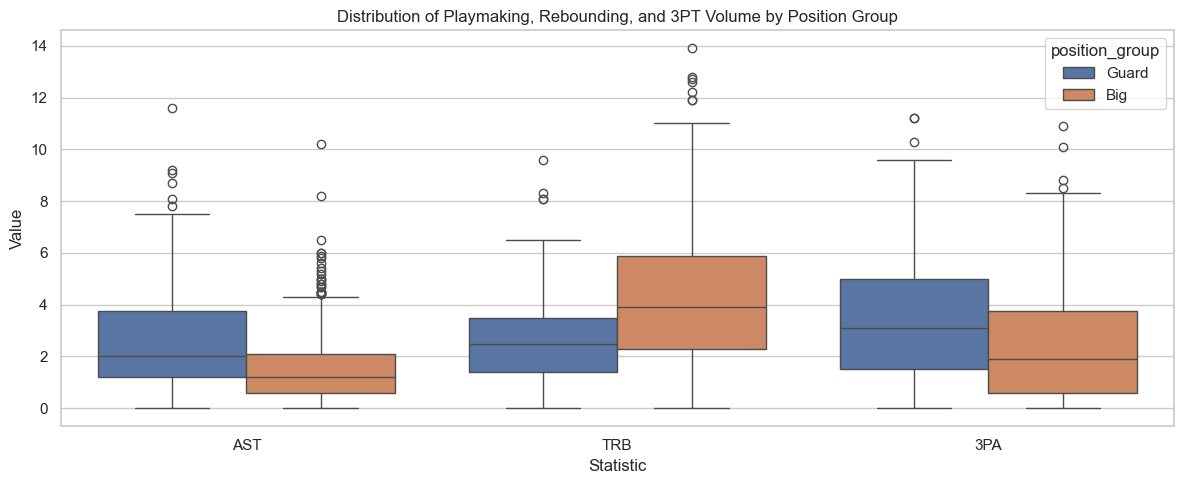

In [51]:
# boxplots for AST, TRB, 3PA by position group
plot_df = eda_df[["position_group", "AST", "TRB", "3PA"]].melt(id_vars="position_group", var_name="Stat", value_name="Value")

plt.figure(figsize=(12, 5))
sns.boxplot(data=plot_df, x="Stat", y="Value", hue="position_group")
plt.title("Distribution of Playmaking, Rebounding, and 3PT Volume by Position Group")
plt.xlabel("Statistic")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

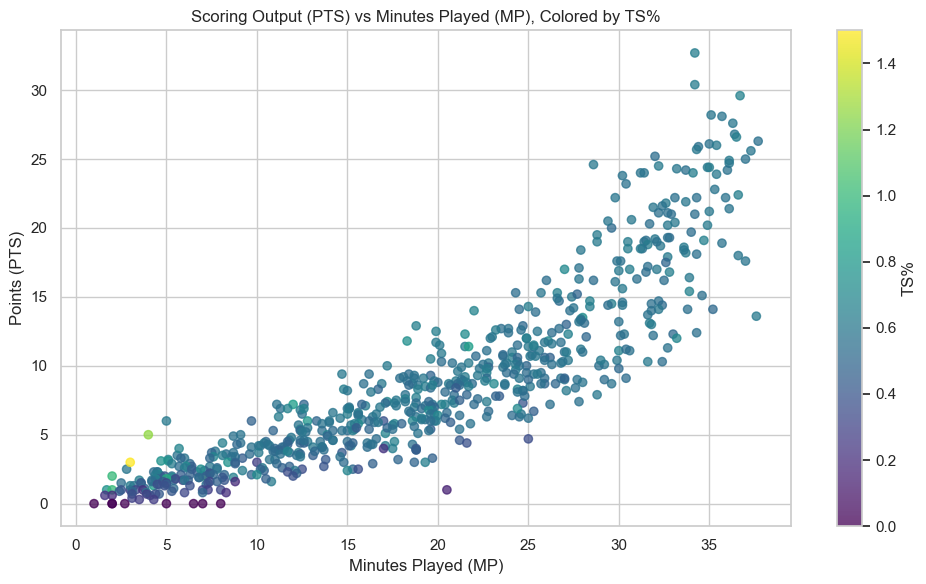

In [52]:
# MP vs PTS colored by TS%
plt.figure(figsize=(10, 6))
scatter = plt.scatter(eda_df["MP"], eda_df["PTS"], c=eda_df["TS%"], cmap="viridis", alpha=0.75)
plt.colorbar(scatter, label="TS%")
plt.title("Scoring Output (PTS) vs Minutes Played (MP), Colored by TS%")
plt.xlabel("Minutes Played (MP)")
plt.ylabel("Points (PTS)")
plt.tight_layout()
plt.show()

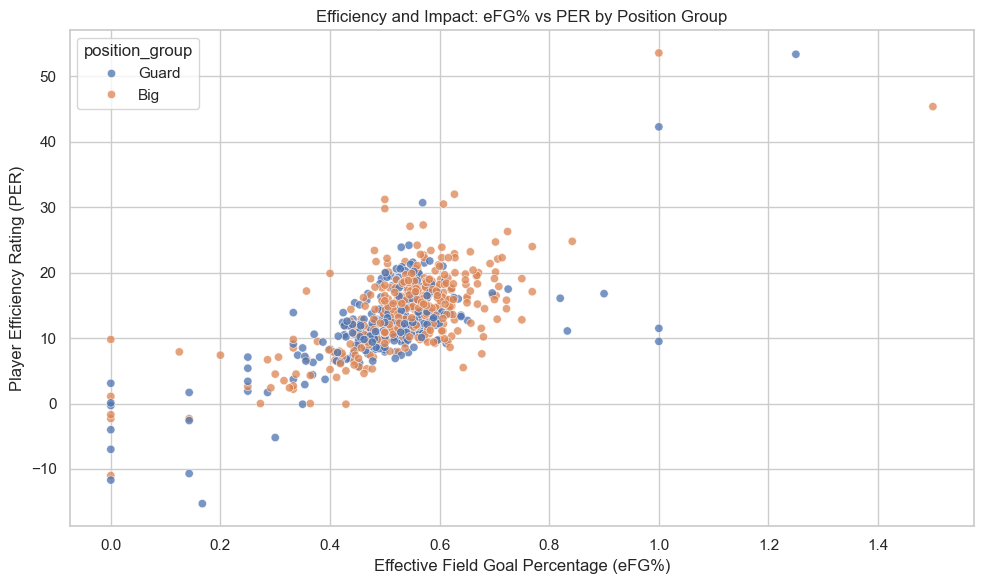

In [53]:
# eFG% vs PER by position group
plt.figure(figsize=(10, 6))
sns.scatterplot(data=eda_df, x="eFG%", y="PER", hue="position_group", alpha=0.75)
plt.title("Efficiency and Impact: eFG% vs PER by Position Group")
plt.xlabel("Effective Field Goal Percentage (eFG%)")
plt.ylabel("Player Efficiency Rating (PER)")
plt.tight_layout()
plt.show()

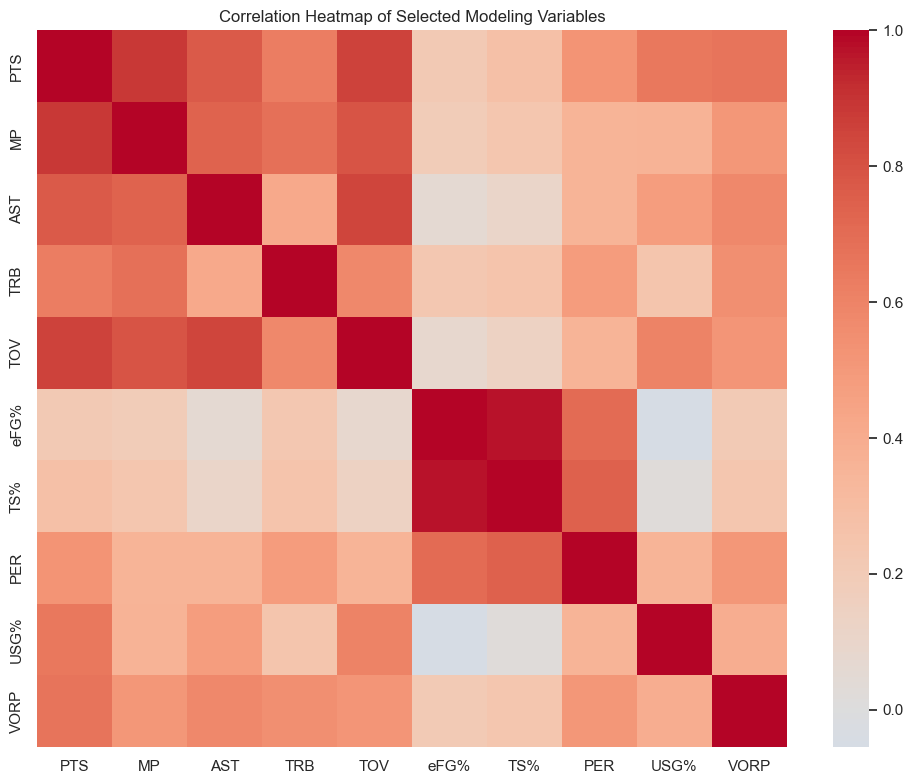

In [54]:
# selected-feature correlation heatmap
corr_features = ["PTS", "MP", "AST", "TRB", "TOV", "eFG%", "TS%", "PER", "USG%", "VORP"]
corr_features = [c for c in corr_features if c in eda_df.columns]

plt.figure(figsize=(10, 8))
sns.heatmap(eda_df[corr_features].corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap of Selected Modeling Variables")
plt.tight_layout()
plt.show()

The EDA is consistent with expected broad role patterns: guards generally show higher playmaking and perimeter attempt volume, while bigs tend to contribute more in rebounding-oriented profiles.

Scoring volume is strongly associated with playing time (`MP`), and efficiency (`TS%`, `eFG%`) provides additional separation among players with similar opportunities.

Efficiency metrics are also positively associated with `PER`, which is consistent with how advanced impact summaries reward productive and efficient play. These are statistical associations and should not be interpreted as causal effects.

## Regression Analysis

### Predicting PTS

In [55]:
# Regression subset and missing value handling
player_stats_reg = player_stats[(player_stats["Player"] != "League Average") & (player_stats["Team"] != "2TM")].copy()

numerical_cols = player_stats_reg.select_dtypes(include=["number"]).columns.tolist()
for col in numerical_cols:
    if player_stats_reg[col].isnull().any():
        player_stats_reg[col].fillna(player_stats_reg[col].mean(), inplace=True)

print('Updated missing values:')
print(player_stats_reg.isnull().sum()[player_stats_reg.isnull().sum() > 0])

Updated missing values:
Awards    607
dtype: int64


Scoring is arguably one of the most important factors in basketball outcomes, so predicting player `PTS` is a central modeling task. Regression helps quantify how performance metrics relate to scoring output, but this baseline uses nearly all numeric predictors, including variables closely tied to point construction.

As a result, near-perfect performance should be interpreted as expected target overlap (closer to reconstruction than fully independent prediction) rather than a surprising discovery.

In [56]:
#remove our y variable (pts)
numerical_cols_no_pts = [col for col in numerical_cols if col != 'PTS']

#create train and test sets to fit and test the following models
X = player_stats_reg[numerical_cols_no_pts]
y = player_stats_reg['PTS']

# Split the data into training and testing sets using 80/20% split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (526, 45)
X_test shape: (132, 45)
y_train shape: (526,)
y_test shape: (132,)


In [57]:
# Initialize and train the Linear Regression model on train data
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Squared Error (MSE): 0.01
R-squared (R2): 1.00


To make the task more meaningful, we next remove direct scoring ingredients (`FG`, `FGA`, `3P`, `FT`, etc.). This helps ensure the model is making genuine predictions from broader player profile information rather than mostly reproducing point totals through mechanical scoring components.

We then evaluate whether non-scoring or broader impact variables still explain substantial variation in `PTS`.

In [58]:
#remove variables directly tied to scoring
scoring_features = ["FG", "FGA", "FG%", "3P", "3PA", "3P%", "2P", "2PA", "2P%", "eFG%", "FT", "FTA", "FT%"]
nonscoring_numeric = [col for col in numerical_cols_no_pts if col not in scoring_features]

#create new x and y variables
X = player_stats_reg[nonscoring_numeric]
y = player_stats_reg['PTS']

#split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (526, 32)
X_test shape: (132, 32)
y_train shape: (526,)
y_test shape: (132,)


In [59]:
#fit linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Squared Error (MSE): 1.71
R-squared (R2): 0.96


In [60]:
print("number of model coefficients")
print(len(model.coef_))

print("Coefficient Values:")
for feature, coef_val in zip(nonscoring_numeric, model.coef_):
    print(f"{feature}: {coef_val:.4f}")

number of model coefficients
32
Coefficient Values:
Age: -0.0177
G: 0.0100
GS: 0.0133
MP: 0.4355
ORB: -0.3303
DRB: 0.3309
TRB: -0.1059
AST: -0.5824
STL: -0.6677
BLK: 0.0652
TOV: 1.8492
PF: -0.1615
PER: -0.0630
TS%: -4.5849
3PAr: -1.3627
FTr: 0.7009
ORB%: 0.1681
DRB%: 0.2294
TRB%: -0.5372
AST%: -0.0303
STL%: -0.1400
BLK%: -0.1262
TOV%: -0.0070
USG%: 0.3513
OWS: -0.0483
DWS: -1.5273
WS: 0.0443
WS/48: 17.8540
OBPM: 0.3094
DBPM: 0.3398
BPM: -0.2841
VORP: 1.5754


Lasso regression is used next to shrink coefficients, reduce weaker or irrelevant terms to zero, and improve interpretability through variable selection.

To avoid leakage and keep coefficient shrinkage comparable across features, scaling is fit on training data and applied to test data.

In [61]:
#create lasso model with k = 10 CV using train-only scaling
scaler_lasso = StandardScaler()
X_train_scaled = scaler_lasso.fit_transform(X_train)
X_test_scaled = scaler_lasso.transform(X_test)

lasso_cv_model = LassoCV(cv=10, max_iter=100000, random_state=11)
lasso_cv_model.fit(X_train_scaled, y_train)

#get optimal lambda value found from CV
optimal_lambda = lasso_cv_model.alpha_
print(f"Optimal lambda value: {optimal_lambda:.4f}")

#now make predictions on test set
y_pred = lasso_cv_model.predict(X_test_scaled)

#evaluate model
mse = mean_squared_error(y_test, y_pred)
R2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {R2:.2f}")

for var, coef in zip(nonscoring_numeric, lasso_cv_model.coef_):
    print(f"{var}: {coef:.4f}")

Optimal lambda value: 0.0059
Mean Squared Error (MSE): 1.75
R-squared (R2): 0.95
Age: -0.0624
G: 0.1859
GS: 0.2983
MP: 4.1518
ORB: -0.2985
DRB: 0.3278
TRB: 0.0000
AST: -0.9007
STL: -0.3015
BLK: 0.0000
TOV: 1.4829
PF: -0.0624
PER: 0.0000
TS%: -0.5563
3PAr: -0.2559
FTr: 0.1553
ORB%: -0.3369
DRB%: -0.0000
TRB%: -0.4041
AST%: -0.2999
STL%: -0.1342
BLK%: -0.1885
TOV%: -0.0665
USG%: 1.9166
OWS: 0.0000
DWS: -1.2451
WS: -0.0000
WS/48: 1.5155
OBPM: 0.0000
DBPM: 0.0302
BPM: 0.0508
VORP: 1.6309


In [62]:
#get variable names and coeff values
lasso_coef = pd.DataFrame({"variable": nonscoring_numeric, "Coefficient": lasso_cv_model.coef_})

# Filter out features with zero coefficients (those removed by Lasso)
important_features = lasso_coef[lasso_coef['Coefficient'] != 0].sort_values(by='Coefficient', ascending=False)

print("Important Features (Non-Zero Coefficients from Lasso):")
display(important_features)

Important Features (Non-Zero Coefficients from Lasso):


,variable,Coefficient
3,MP,4.151756
23,USG%,1.916610
31,VORP,1.630914
27,WS/48,1.515470
10,TOV,1.482922
5,DRB,0.327804
2,GS,0.298314
1,G,0.185864
15,FTr,0.155259
30,BPM,0.050819


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_15732\2040063579.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='variable', data=important_features, palette='viridis')


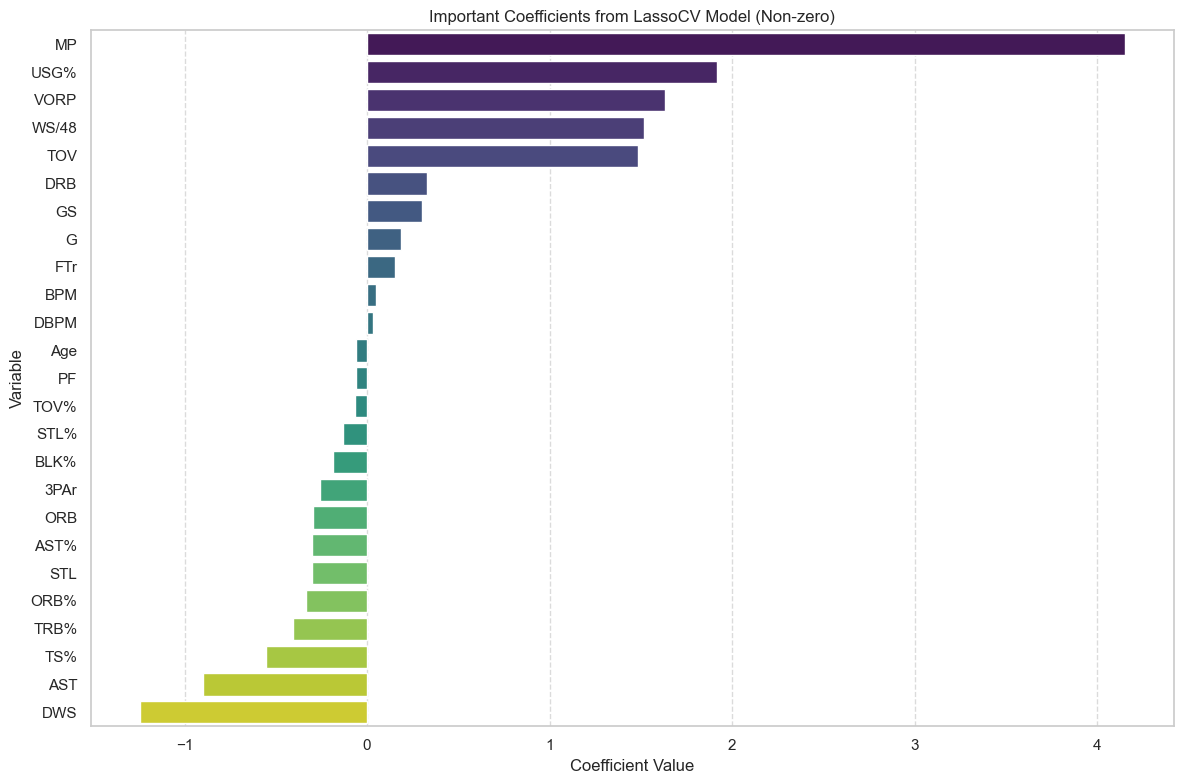

In [63]:
# Plotting the important coefficients
plt.figure(figsize=(12, 8))
sns.barplot(x='Coefficient', y='variable', data=important_features, palette='viridis')
plt.title('Important Coefficients from LassoCV Model (Non-zero)')
plt.xlabel('Coefficient Value')
plt.ylabel('Variable')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The refined `PTS` models remain strongly predictive after removing direct shot-construction variables, making this a more meaningful prediction exercise.

Lasso provides a useful trade-off: slightly lower fit, better interpretability, and clearer variable selection. In this setting, high-value impact indicators such as `VORP` remain informative for scoring prediction outside direct scoring inputs.

### Predicting PER

In [64]:
#define response variable
y_per = player_stats_reg['PER']

#We will use all the basic variables from our player_basic data set
basic_stats_cols = [
    'G', 'GS', 'MP', 'FG', 'FGA', 'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%',
    'eFG%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS'
]
X_basic_stats = player_stats_reg[basic_stats_cols]

print(f"Shape of y_per: {y_per.shape}")
print(f"Shape of X_basic_stats: {X_basic_stats.shape}")
display(X_basic_stats.head())

Shape of y_per: (658,)
Shape of X_basic_stats: (658, 25)


,G,GS,MP,FG,FGA,FG%,3P,3PA,3P%,2P,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
0,76.0,76.0,34.2,11.3,21.8,0.519,2.1,5.7,0.375,9.2,...,0.898,0.9,4.1,5.0,6.4,1.7,1.0,2.4,2.2,32.7
1,67.0,67.0,34.2,11.8,19.7,0.601,0.2,0.9,0.222,11.6,...,0.617,2.2,9.7,11.9,6.5,0.9,1.2,3.1,2.3,30.4
2,70.0,70.0,36.7,11.2,19.5,0.576,2.0,4.7,0.417,9.3,...,0.800,2.9,9.9,12.7,10.2,1.8,0.6,3.3,2.3,29.6
4,22.0,22.0,35.7,9.8,21.2,0.464,3.4,9.6,0.354,6.4,...,0.767,0.7,7.6,8.3,7.8,2.0,0.4,3.4,2.6,28.1
5,28.0,28.0,35.1,8.8,20.0,0.438,3.6,9.6,0.379,5.1,...,0.791,0.9,7.2,8.1,7.5,1.6,0.4,3.7,2.4,28.2


`PER` is an advanced, constructed metric intended to summarize a player's per-minute impact by combining positive and negative box-score contributions.

We begin with linear regression on basic box-score predictors. This is best interpreted as approximation of an existing composite formula rather than discovery of causal player value.

In [65]:
# Split the data into training and testing sets using 80/20 split
X_train_per, X_test_per, y_train_per, y_test_per = train_test_split(X_basic_stats, y_per, test_size=0.2, random_state=11)

# fill missing values using train medians only
train_medians_per = X_train_per.median(numeric_only=True)
X_train_per = X_train_per.fillna(train_medians_per)
X_test_per = X_test_per.fillna(train_medians_per)

print(f"X_train_per shape: {X_train_per.shape}")
print(f"X_test_per shape: {X_test_per.shape}")
print(f"y_train_per shape: {y_train_per.shape}")
print(f"y_test_per shape: {y_test_per.shape}")

# Initialize and train the Linear Regression model
per_model = LinearRegression()
per_model.fit(X_train_per, y_train_per)

# Make predictions on the test set
y_pred_per = per_model.predict(X_test_per)

#evaluate model
mse = mean_squared_error(y_test_per, y_pred_per)
R2 = r2_score(y_test_per, y_pred_per)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {R2:.2f}")

X_train_per shape: (526, 25)
X_test_per shape: (132, 25)
y_train_per shape: (526,)
y_test_per shape: (132,)
Mean Squared Error (MSE): 6.04
R-squared (R2): 0.81


In [66]:
#create lasso model, using cv = 10 to find optimal lambda (with train-only scaling)
scaler_per = StandardScaler()
X_train_per_scaled = scaler_per.fit_transform(X_train_per)
X_test_per_scaled = scaler_per.transform(X_test_per)

Lasso_CV_per = LassoCV(cv=10, random_state=11, max_iter=10000)
Lasso_CV_per.fit(X_train_per_scaled, y_train_per)

optimal_lambda = Lasso_CV_per.alpha_
print(f"Optimal Lambda Found: {optimal_lambda:.4f}")

#predict on test data
y_pred_per = Lasso_CV_per.predict(X_test_per_scaled)

#evaluate model
mse = mean_squared_error(y_test_per, y_pred_per)
R2 = r2_score(y_test_per, y_pred_per)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {R2:.2f}")

#get variable names and coeff values
lasso_coef_per = pd.DataFrame({"variable": X_train_per.columns, "Coefficient": Lasso_CV_per.coef_})
important_features = lasso_coef_per[lasso_coef_per['Coefficient'] != 0].sort_values(by='Coefficient', ascending=False)

print("Important Features (Non-Zero Coefficients from Lasso):")
display(important_features)
print("Number of features", len(important_features))

Optimal Lambda Found: 0.0119
Mean Squared Error (MSE): 5.92
R-squared (R2): 0.81
Important Features (Non-Zero Coefficients from Lasso):


,variable,Coefficient
5,FG%,3.184285
19,AST,2.014794
6,3P,1.900286
4,FGA,1.623222
18,TRB,1.504914
20,STL,1.436770
10,2PA,1.294391
12,eFG%,1.258563
16,ORB,1.016761
14,FTA,0.818126


Number of features 20


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_15732\4052839912.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='variable', data=important_features, palette='viridis')


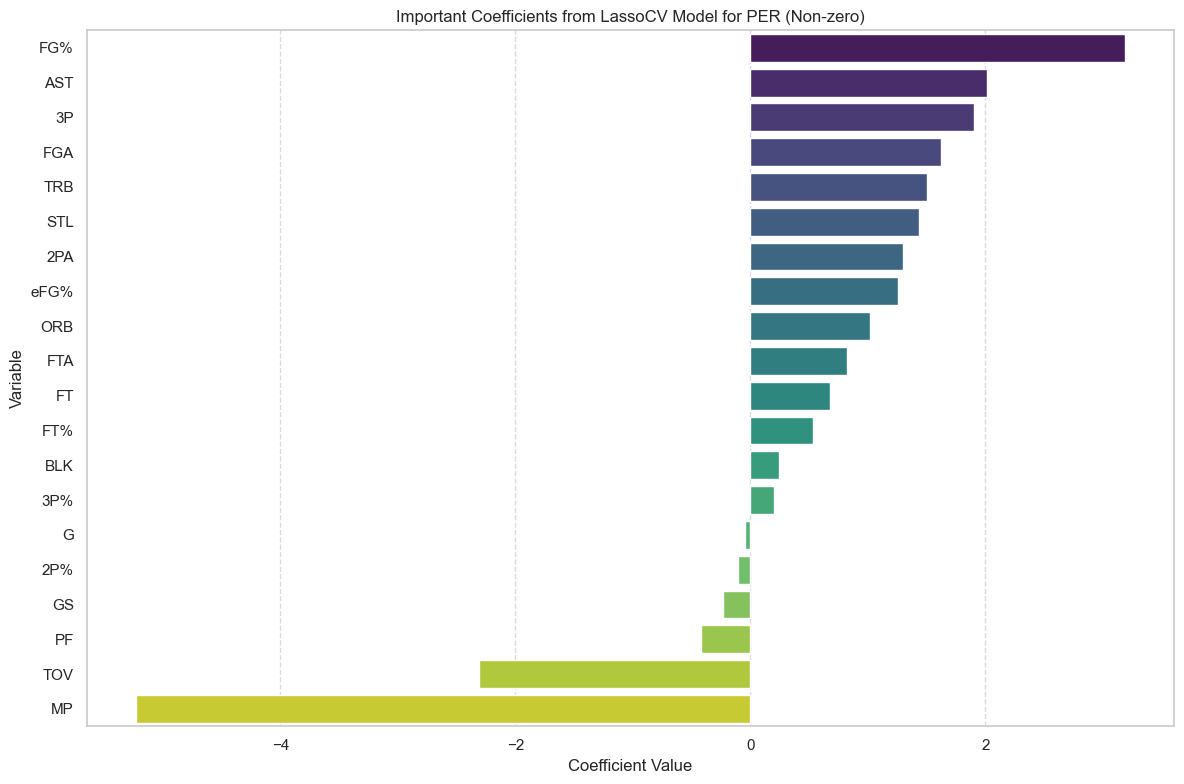

In [67]:
# Plotting the important coefficients for PER prediction
plt.figure(figsize=(12, 8))
sns.barplot(x='Coefficient', y='variable', data=important_features, palette='viridis')
plt.title('Important Coefficients from LassoCV Model for PER (Non-zero)')
plt.xlabel('Coefficient Value')
plt.ylabel('Variable')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

To capture potential non-linear relationships, we add polynomial terms. This can improve fit by modeling curved and interaction patterns that linear models miss.

Because these transforms learn feature mappings, they are fit on training data only and then applied to the test set. We interpret any gains cautiously because added dimensionality can increase overfitting risk.

In [68]:
#create polynomial features with train-test separation
X_train_per_raw, X_test_per_raw, y_train_per, y_test_per = train_test_split(X_basic_stats, y_per, test_size=0.2, random_state=11)

train_medians_poly = X_train_per_raw.median(numeric_only=True)
X_train_per_raw = X_train_per_raw.fillna(train_medians_poly)
X_test_per_raw = X_test_per_raw.fillna(train_medians_poly)

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_per_raw)
X_test_poly = poly.transform(X_test_per_raw)

print("New number of features", X_train_poly.shape[1])

#create and fit model
per_model_poly = LinearRegression()
per_model_poly.fit(X_train_poly, y_train_per)

#make predictions
y_pred = per_model_poly.predict(X_test_poly)

#evaluate model
mse = mean_squared_error(y_test_per, y_pred)
R2 = r2_score(y_test_per, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {R2:.2f}")

New number of features 350
Mean Squared Error (MSE): 11.00
R-squared (R2): 0.65


### Selected Polynomial Terms for PER Prediction

We now add degree-2 polynomial terms only for selected features (`eFG%`, `TOV`, `MP`). These were chosen because earlier models suggested they are influential for `PER` and may plausibly have non-linear effects.

This targeted expansion balances model flexibility and interpretability, avoiding the much larger feature growth from full polynomial expansion.

In [69]:
# Select important variables
selected_poly_features = ['eFG%', 'TOV', 'MP']

# Split first to avoid leakage
X_train_base, X_test_base, y_train_per, y_test_per = train_test_split(X_basic_stats, y_per, test_size=0.2, random_state=11)
train_medians_selected = X_train_base.median(numeric_only=True)
X_train_base = X_train_base.fillna(train_medians_selected)
X_test_base = X_test_base.fillna(train_medians_selected)

# Create polynomial features for selected variables (degree 2)
poly_selected = PolynomialFeatures(degree=2, include_bias=False)
X_train_selected_poly = poly_selected.fit_transform(X_train_base[selected_poly_features])
X_test_selected_poly = poly_selected.transform(X_test_base[selected_poly_features])

# Get the names of the new polynomial features
poly_feature_names = poly_selected.get_feature_names_out(selected_poly_features)

# Create DataFrames and combine with original features
X_train_selected_poly_df = pd.DataFrame(X_train_selected_poly, columns=poly_feature_names, index=X_train_base.index)
X_test_selected_poly_df = pd.DataFrame(X_test_selected_poly, columns=poly_feature_names, index=X_test_base.index)

X_train_per_combined_poly = pd.concat([X_train_base, X_train_selected_poly_df], axis=1)
X_test_per_combined_poly = pd.concat([X_test_base, X_test_selected_poly_df], axis=1)

print(f"Original number of features: {X_basic_stats.shape[1]}")
print(f"Number of features after adding selected polynomial terms: {X_train_per_combined_poly.shape[1]}")

# Initialize and train a Linear Regression model on the combined features
per_model_combined_poly = LinearRegression()
per_model_combined_poly.fit(X_train_per_combined_poly, y_train_per)

# Make predictions on the test set
y_pred_per_combined_poly = per_model_combined_poly.predict(X_test_per_combined_poly)

# Evaluate the model
mse_combined_poly = mean_squared_error(y_test_per, y_pred_per_combined_poly)
r2_combined_poly = r2_score(y_test_per, y_pred_per_combined_poly)

print(f"Mean Squared Error (MSE) with Selected Polynomial Features: {mse_combined_poly:.2f}")
print(f"R-squared (R2) with Selected Polynomial Features: {r2_combined_poly:.2f}")

Original number of features: 25
Number of features after adding selected polynomial terms: 34
Mean Squared Error (MSE) with Selected Polynomial Features: 6.52
R-squared (R2) with Selected Polynomial Features: 0.79


In [70]:
# Coefficient table for selected polynomial model
coef_df_combined_poly = pd.DataFrame({
    'Feature': X_train_per_combined_poly.columns,
    'Coefficient': per_model_combined_poly.coef_
}).sort_values(by='Coefficient', ascending=False)

display(coef_df_combined_poly.head(10))

,Feature,Coefficient
5,FG%,37.079433
28,eFG%^2,7.809682
6,3P,4.730249
15,FT%,4.197354
20,STL,3.255599
9,2P,2.833125
24,PTS,1.863679
16,ORB,1.773585
3,FG,1.476597
8,3P%,1.273991


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_15732\2637057559.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coef_df_combined_poly.head(10), palette='viridis')


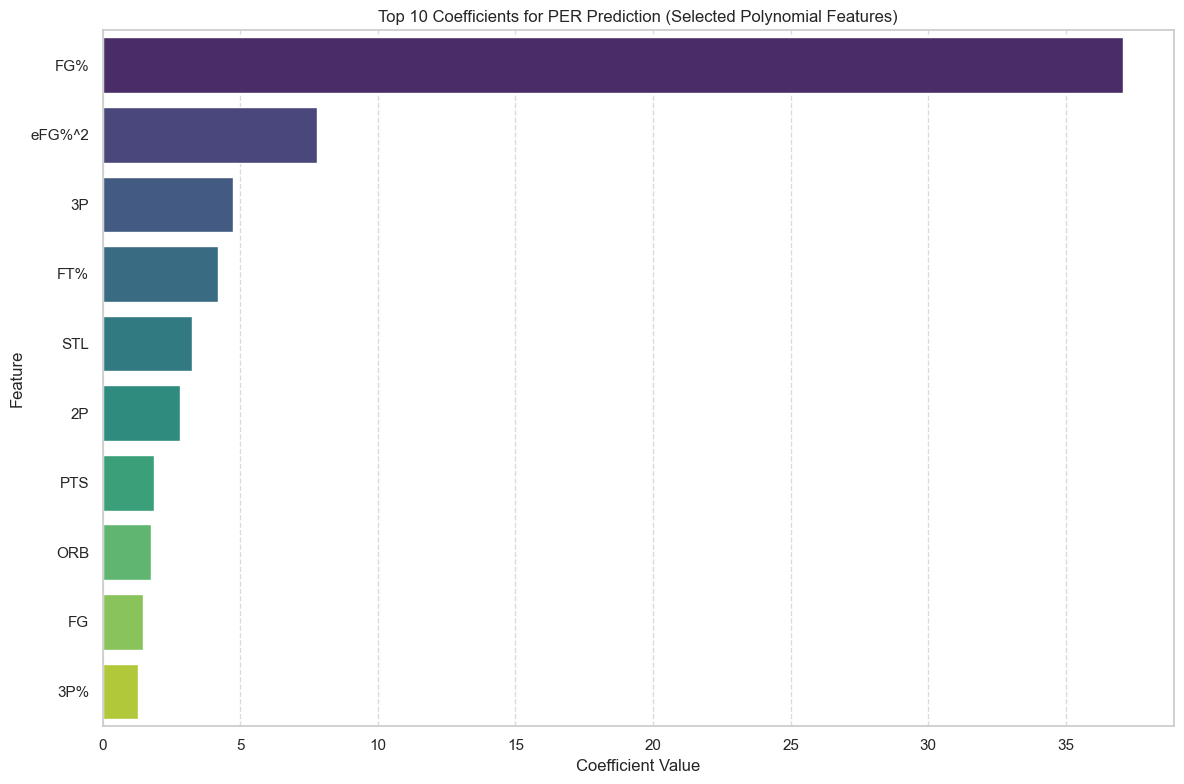

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_15732\2637057559.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coef_df_combined_poly.tail(10), palette='viridis')


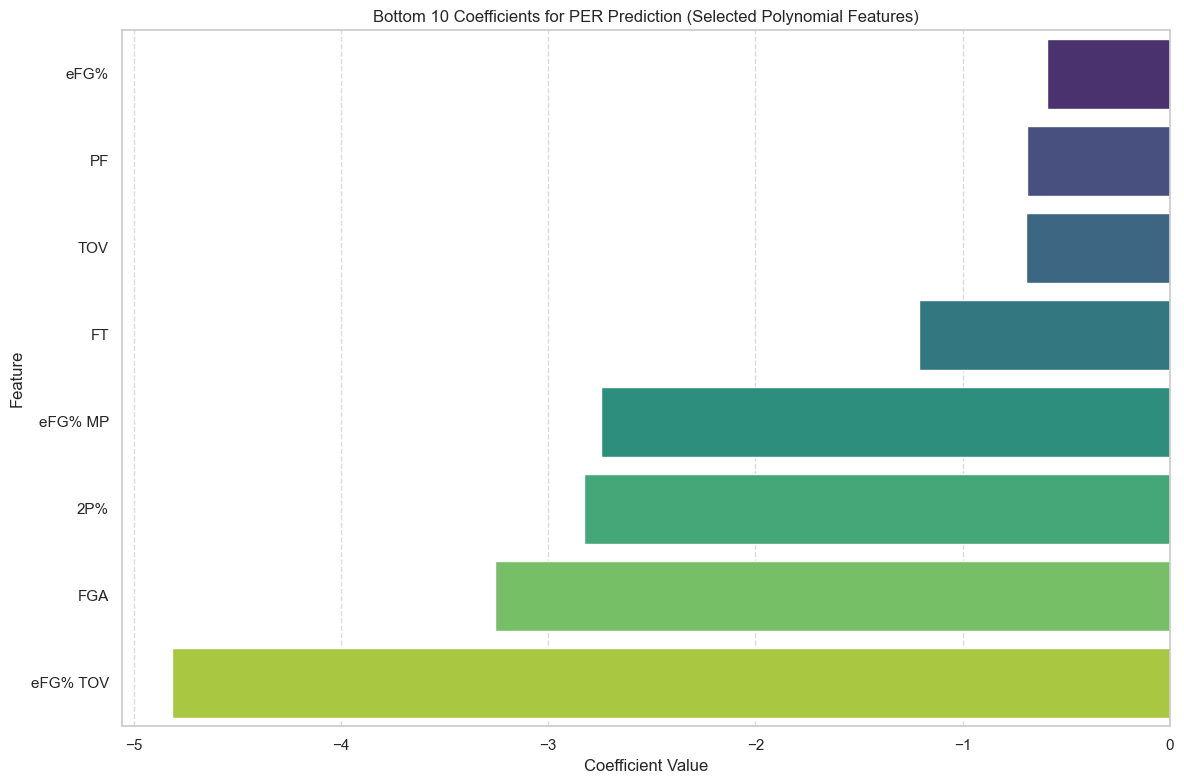

In [71]:
# Plotting the top 10 coefficients for the model with selected polynomial terms
plt.figure(figsize=(12, 8))
sns.barplot(x='Coefficient', y='Feature', data=coef_df_combined_poly.head(10), palette='viridis')
plt.title('Top 10 Coefficients for PER Prediction (Selected Polynomial Features)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plotting the bottom 10 coefficients for the model with selected polynomial terms
plt.figure(figsize=(12, 8))
sns.barplot(x='Coefficient', y='Feature', data=coef_df_combined_poly.tail(10), palette='viridis')
plt.title('Bottom 10 Coefficients for PER Prediction (Selected Polynomial Features)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Regression summary: refined `PTS` models remained highly predictive even after excluding direct scoring ingredients, and this version is more meaningful than overlap-heavy baselines that include direct point-construction variables.

Lasso improved interpretability through shrinkage and variable selection, with a modest performance trade-off. `PER` was reasonably estimable from basic box-score variables as an approximation task for a constructed advanced metric, while non-linear terms improved fit at the cost of greater complexity and overfitting risk.

Selected polynomial terms (`eFG%`, `TOV`, `MP`) provided a practical compromise between predictive performance and interpretability.

## Classification

### Logistic Regression

We classify players into a simplified binary role group (`Guard` vs `Big`) using statistical profiles. This target is intentionally coarse; some wing or hybrid players are expected to sit near the boundary and may be misclassified.

              precision    recall  f1-score   support

           0       0.74      0.89      0.81        64
           1       0.87      0.71      0.78        68

    accuracy                           0.80       132
   macro avg       0.81      0.80      0.79       132
weighted avg       0.81      0.80      0.79       132

[[57  7]
 [20 48]]


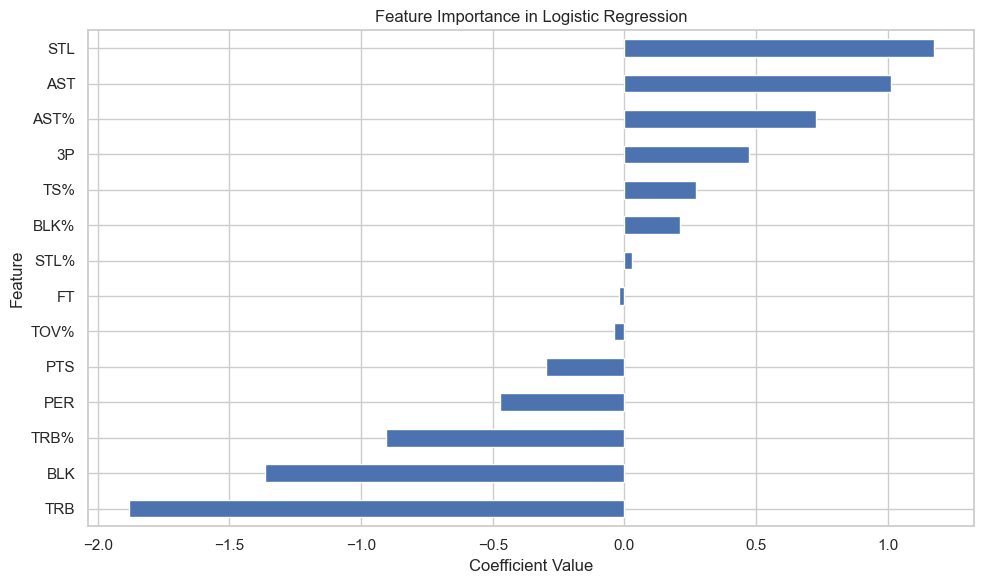

           Player Pos predicted_position
22   LeBron James  SF              Guard
25   Franz Wagner  SF              Guard
35    Zach LaVine  SF              Guard
39   Jaylen Brown  SF              Guard
40  DeMar DeRozan  SF              Guard


In [72]:
player_model = player_stats[(player_stats["Player"] != "League Average") & (player_stats["Team"] != "2TM")].copy()

# create target variable: 1 if guard, 0 if big
player_model["is_guard"] = player_model["Pos"].astype(str).str.contains("G", na=False).astype(int)

# select features and target
features = [
    "PTS", "AST", "TRB", "STL", "BLK", "3P", "FT",
    "PER", "TS%", "TRB%", "AST%", "STL%", "BLK%", "TOV%",
]
X = player_model[features]
y = player_model["is_guard"]

# split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# train-only median imputation and scaling
train_medians = X_train.median(numeric_only=True)
X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians)

scaler_cls = StandardScaler()
X_train_scaled = scaler_cls.fit_transform(X_train)
X_test_scaled = scaler_cls.transform(X_test)

# fit logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

# make predictions and evaluate
y_pred = model.predict(X_test_scaled)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

# visualize feature importance
feature_importance = pd.Series(model.coef_[0], index=features).sort_values()
plt.figure(figsize=(10, 6))
feature_importance.plot(kind="barh")
plt.title("Feature Importance in Logistic Regression")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# add predicted position label to original dataframe
X_all = player_model[features].fillna(train_medians)
player_model["predicted_position"] = np.where(model.predict(scaler_cls.transform(X_all)) == 1, "Guard", "Big")

# display mislabelled players (misclassified by the model)
mislabelled_players = player_model[
    (player_model["Pos"].str.contains("G") & (player_model["predicted_position"] == "Big"))
    | (player_model["Pos"].str.contains("F|C") & (player_model["predicted_position"] == "Guard"))
]
print(mislabelled_players[["Player", "Pos", "predicted_position"]].head(5))

### Logistic Regression (Hybrid Stats)

Using mixed basic and advanced features generally improves separation of broad role groups, but wing players with hybrid profiles are still common boundary cases.

### Logistic Regression (Basic Stats)

=== Player Basic Stats Model ===
              precision    recall  f1-score   support

           0       0.75      0.88      0.81        64
           1       0.86      0.72      0.78        68

    accuracy                           0.80       132
   macro avg       0.80      0.80      0.79       132
weighted avg       0.80      0.80      0.79       132

[[56  8]
 [19 49]]


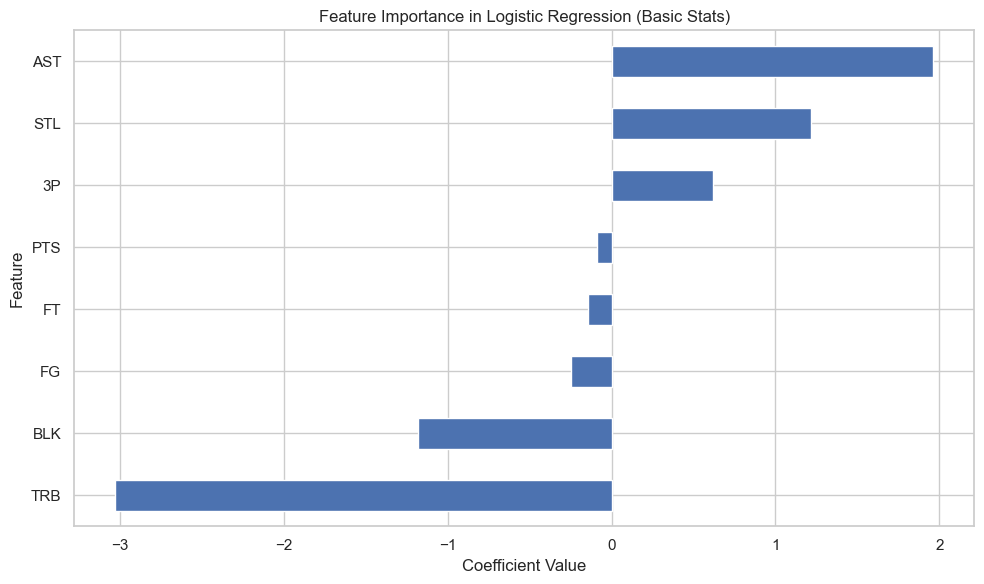

           Player Pos predicted_position
22   LeBron James  SF              Guard
25   Franz Wagner  SF              Guard
35    Zach LaVine  SF              Guard
39   Jaylen Brown  SF              Guard
40  DeMar DeRozan  SF              Guard


In [73]:
# Logistic Regression on player_basic dataset
player_model_basic = player_basic[(player_basic["Player"] != "League Average") & (player_basic["Team"] != "2TM")].copy()

# create target variable: 1 if guard, 0 if big
player_model_basic["is_guard"] = player_model_basic["Pos"].astype(str).str.contains("G", na=False).astype(int)

# select features and target (basic stats)
features_basic = ["PTS", "AST", "TRB", "STL", "BLK", "3P", "FT", "FG"]
X_basic = player_model_basic[features_basic]
y_basic = player_model_basic["is_guard"]

# split data into train and test sets
X_train_basic, X_test_basic, y_train_basic, y_test_basic = train_test_split(X_basic, y_basic, test_size=0.2, random_state=42)

# train-only preprocessing
train_medians_basic = X_train_basic.median(numeric_only=True)
X_train_basic = X_train_basic.fillna(train_medians_basic)
X_test_basic = X_test_basic.fillna(train_medians_basic)

scaler_basic_cls = StandardScaler()
X_train_basic_scaled = scaler_basic_cls.fit_transform(X_train_basic)
X_test_basic_scaled = scaler_basic_cls.transform(X_test_basic)

# fit logistic regression model
model_basic = LogisticRegression(max_iter=1000)
model_basic.fit(X_train_basic_scaled, y_train_basic)

# make predictions and evaluate
y_pred_basic = model_basic.predict(X_test_basic_scaled)
print("=== Player Basic Stats Model ===")
print(classification_report(y_test_basic, y_pred_basic))
print(confusion_matrix(y_test_basic, y_pred_basic))

# visualize feature importance
feature_importance_basic = pd.Series(model_basic.coef_[0], index=features_basic).sort_values()
plt.figure(figsize=(10, 6))
feature_importance_basic.plot(kind="barh")
plt.title("Feature Importance in Logistic Regression (Basic Stats)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# add predicted position label to original dataframe
X_basic_all = X_basic.fillna(train_medians_basic)
player_model_basic["predicted_position"] = np.where(model_basic.predict(scaler_basic_cls.transform(X_basic_all)) == 1, "Guard", "Big")

# display mislabelled players (misclassified by the model)
mislabelled_players_basic = player_model_basic[
    (player_model_basic["Pos"].str.contains("G") & (player_model_basic["predicted_position"] == "Big"))
    | (player_model_basic["Pos"].str.contains("F|C") & (player_model_basic["predicted_position"] == "Guard"))
]
print(mislabelled_players_basic[["Player", "Pos", "predicted_position"]].head(5))

### Logistic Regression (Advanced Stats)

=== Player Advanced Stats Model ===
              precision    recall  f1-score   support

           0       0.84      0.82      0.83        72
           1       0.79      0.82      0.80        60

    accuracy                           0.82       132
   macro avg       0.82      0.82      0.82       132
weighted avg       0.82      0.82      0.82       132

[[59 13]
 [11 49]]


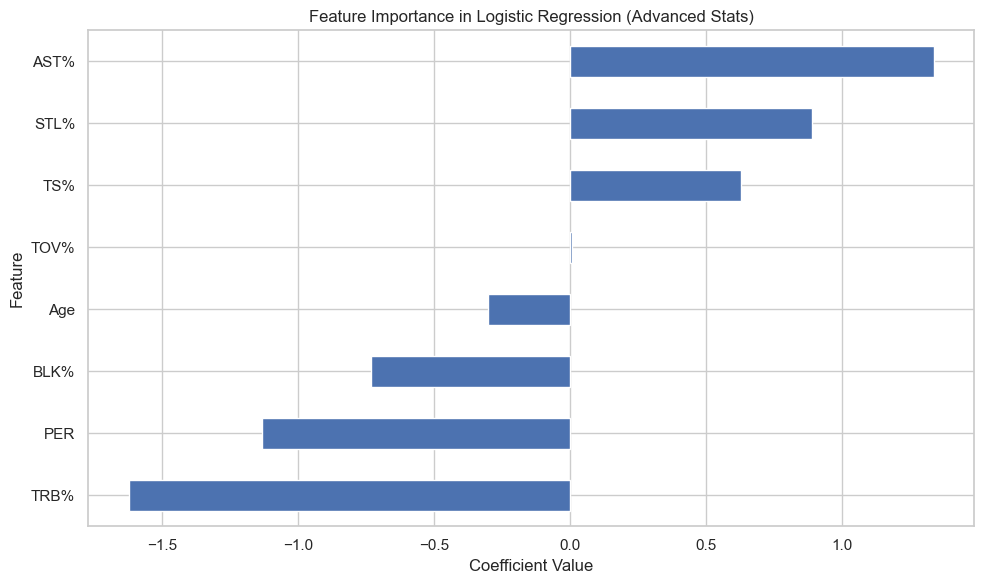

             Player Pos predicted_position
0     Mikal Bridges  SF              Guard
1         Josh Hart  SG                Big
2   Anthony Edwards  SG                Big
10  Christian Braun  SG                Big
17      Zach LaVine  SF              Guard


In [74]:
# Logistic Regression on player_advanced dataset
player_model_adv = player_advanced[(player_advanced["Player"] != "League Average") & (player_advanced["Team"] != "2TM")].copy()

# create target variable: 1 if guard, 0 if big
player_model_adv["is_guard"] = player_model_adv["Pos"].astype(str).str.contains("G", na=False).astype(int)

# select features and target (advanced stats)
features_adv = ["Age", "PER", "TS%", "TRB%", "AST%", "STL%", "BLK%", "TOV%"]
X_adv = player_model_adv[features_adv]
y_adv = player_model_adv["is_guard"]

# split data into train and test sets
X_train_adv, X_test_adv, y_train_adv, y_test_adv = train_test_split(X_adv, y_adv, test_size=0.2, random_state=42)

# train-only preprocessing
train_medians_adv = X_train_adv.median(numeric_only=True)
X_train_adv = X_train_adv.fillna(train_medians_adv)
X_test_adv = X_test_adv.fillna(train_medians_adv)

scaler_adv_cls = StandardScaler()
X_train_adv_scaled = scaler_adv_cls.fit_transform(X_train_adv)
X_test_adv_scaled = scaler_adv_cls.transform(X_test_adv)

# fit logistic regression model
model_adv = LogisticRegression(max_iter=1000)
model_adv.fit(X_train_adv_scaled, y_train_adv)

# make predictions and evaluate
y_pred_adv = model_adv.predict(X_test_adv_scaled)
print("=== Player Advanced Stats Model ===")
print(classification_report(y_test_adv, y_pred_adv))
print(confusion_matrix(y_test_adv, y_pred_adv))

# visualize feature importance
feature_importance_adv = pd.Series(model_adv.coef_[0], index=features_adv).sort_values()
plt.figure(figsize=(10, 6))
feature_importance_adv.plot(kind="barh")
plt.title("Feature Importance in Logistic Regression (Advanced Stats)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# add predicted position label to original dataframe
X_adv_all = X_adv.fillna(train_medians_adv)
player_model_adv["predicted_position"] = np.where(model_adv.predict(scaler_adv_cls.transform(X_adv_all)) == 1, "Guard", "Big")

# display mislabelled players (misclassified by the model)
mislabelled_players_adv = player_model_adv[
    (player_model_adv["Pos"].str.contains("G") & (player_model_adv["predicted_position"] == "Big"))
    | (player_model_adv["Pos"].str.contains("F|C") & (player_model_adv["predicted_position"] == "Guard"))
]
print(mislabelled_players_adv[["Player", "Pos", "predicted_position"]].head(5))

Classification summary: these models capture broad statistical role tendencies rather than exact official position labels. Advanced/hybrid features often help by compactly encoding efficiency and role tendencies, while many wings remain naturally ambiguous between guard-like and big-like profiles.

## Clustering

### Hierarchical Clustering

Clustering is used here as an exploratory method to identify player archetypes without predefined labels.

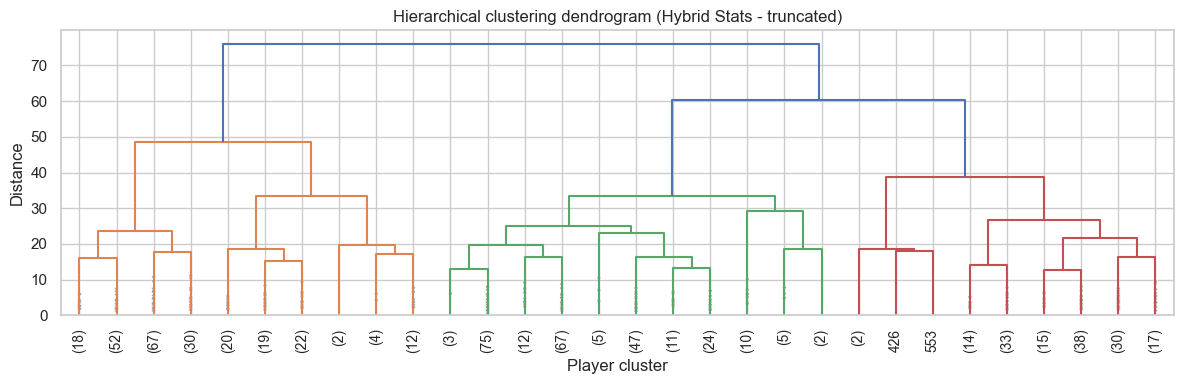

n_clusters=4; unique clusters=4
silhouette score: 0.116
cluster
0    151
1     79
2    261
3    167
Name: count, dtype: int64

Cluster 0 players:
              Player Team Pos
64      John Collins  UTA  PF
106    Mark Williams  CHO   C
114  P.J. Washington  DAL  PF
119     Jakob Poeltl  TOR   C
120    Deandre Ayton  POR   C
130       Tolu Smith  DET  PF
132     Bobby Portis  MIL  PF
136   Onyeka Okongwu  ATL   C
145        Alex Sarr  WAS   C
146    Moritz Wagner  ORL   C

Cluster 0 mean stats:
PER      12.139855
TS%       0.537746
3PAr      0.427609
FTr       0.242826
ORB%      6.284783
DRB%     15.007246
TRB%     10.622464
AST%     12.991304
STL%      1.775362
BLK%      2.107246
TOV%     13.000000
USG%     15.970290
OWS       0.498551
DWS       0.628986
WS        1.128986
WS/48     0.075312
OBPM     -2.101449
DBPM      0.068841
BPM      -2.034783
VORP      0.125362
PTS       5.834783
AST       1.514493
TRB       3.037681
STL       0.573913
BLK       0.357971
3P        0.751449
FT     

In [75]:
# Hierarchical Clustering on player_stats (hybrid) dataset
numeric_cols = [
    'PER', 'TS%', '3PAr', 'FTr', 'ORB%', 'DRB%', 'TRB%',
    'AST%', 'STL%', 'BLK%', 'TOV%', 'USG%', 'OWS', 'DWS',
    'WS', 'WS/48', 'OBPM', 'DBPM', 'BPM', 'VORP', 'PTS',
    'AST', 'TRB', 'STL', 'BLK', '3P', 'FT',
]

df_players = player_stats[(player_stats['Player'] != 'League Average') & (player_stats['Team'] != '2TM')].copy()
X_raw = df_players[numeric_cols]
X_clean = X_raw.fillna(X_raw.median())

scaler = StandardScaler()
X = scaler.fit_transform(X_clean)

Z = linkage(X, method='ward')
plt.figure(figsize=(12, 4))
dendrogram(
    Z,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True
)
plt.title('Hierarchical clustering dendrogram (Hybrid Stats - truncated)')
plt.xlabel('Player cluster')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

def cluster_players(n_clusters=4):
    model = AgglomerativeClustering(n_clusters=n_clusters)
    labels = model.fit_predict(X)
    clustered = df_players[['Player', 'Team', 'Pos']].copy()
    clustered['cluster'] = labels
    print(f'n_clusters={n_clusters}; unique clusters={len(np.unique(labels))}')
    if len(np.unique(labels)) > 1:
        print('silhouette score:', round(silhouette_score(X, labels), 3))
    print(clustered.groupby('cluster').size().rename('count'))
    return clustered

clustered_players = cluster_players(4)
cluster_means = pd.concat([X_clean.reset_index(drop=True), clustered_players['cluster']], axis=1).groupby('cluster').mean()

for cluster in range(4):
    print(f"\nCluster {cluster} players:")
    print(clustered_players[clustered_players['cluster'] == cluster][['Player', 'Team', 'Pos']].head(10))
    print(f"\nCluster {cluster} mean stats:")
    print(cluster_means.loc[cluster])

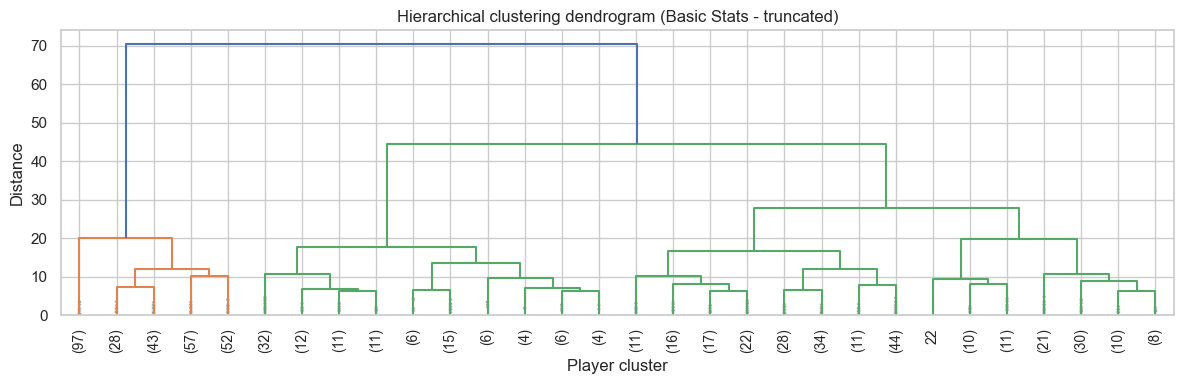

n_clusters=4; unique clusters=4
silhouette score: 0.289
cluster
0    277
1     91
2    107
3    183
Name: count, dtype: int64

Cluster 0 players:
               Player Team Pos
258       A.J. Lawson  TOR  SG
263      Jared Butler  WAS  PG
283      Kelly Olynyk  TOR   C
291       DantÃ© Exum  DAL  PG
293       Jaden Hardy  DAL  SG
302      Jared Rhoden  CHO  SG
304     Jaylen Nowell  NOP  SG
307       Bruce Brown  TOR  PG
312  Brandon Williams  DAL  PG
323      Caleb Martin  DAL  SF

Cluster 0 mean stats:
PTS     3.373786
AST     1.027184
TRB     2.009709
STL     0.404854
BLK     0.239806
3P      0.436408
FT      0.410194
FG      1.267961
MP     10.668932
G      26.320388
Name: 0.0, dtype: float64

Cluster 1 players:
                   Player Team Pos
18          Anthony Davis  DAL  PF
24      Victor Wembanyama  SAS   C
42      Jaren Jackson Jr.  MEM   C
58   Kristaps PorziÅÄ£is  BOS   C
64           John Collins  UTA  PF
70            Evan Mobley  CLE  PF
94            Ivica Zubac  LA

In [76]:
# Hierarchical Clustering on player_basic dataset
numeric_cols_basic = ["PTS", "AST", "TRB", "STL", "BLK", "3P", "FT", "FG", "MP", "G"]

df_players_basic = player_basic[(player_basic['Player'] != 'League Average') & (player_basic['Team'] != '2TM')].copy()
X_raw_basic = df_players_basic[numeric_cols_basic]
X_clean_basic = X_raw_basic.fillna(X_raw_basic.median())

scaler_basic = StandardScaler()
X_basic_scaled = scaler_basic.fit_transform(X_clean_basic)

Z_basic = linkage(X_basic_scaled, method='ward')
plt.figure(figsize=(12, 4))
dendrogram(
    Z_basic,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True
)
plt.title('Hierarchical clustering dendrogram (Basic Stats - truncated)')
plt.xlabel('Player cluster')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

def cluster_players_basic(n_clusters=4):
    model = AgglomerativeClustering(n_clusters=n_clusters)
    labels = model.fit_predict(X_basic_scaled)
    clustered = df_players_basic[['Player', 'Team', 'Pos']].copy()
    clustered['cluster'] = labels
    print(f'n_clusters={n_clusters}; unique clusters={len(np.unique(labels))}')
    if len(np.unique(labels)) > 1:
        print('silhouette score:', round(silhouette_score(X_basic_scaled, labels), 3))
    print(clustered.groupby('cluster').size().rename('count'))
    return clustered

clustered_players_basic = cluster_players_basic(4)
cluster_means_basic = pd.concat([X_clean_basic.reset_index(drop=True), clustered_players_basic['cluster']], axis=1).groupby('cluster').mean()

for cluster in range(4):
    print(f"\nCluster {cluster} players:")
    print(clustered_players_basic[clustered_players_basic['cluster'] == cluster][['Player', 'Team', 'Pos']].head(10))
    print(f"\nCluster {cluster} mean stats:")
    print(cluster_means_basic.loc[cluster])

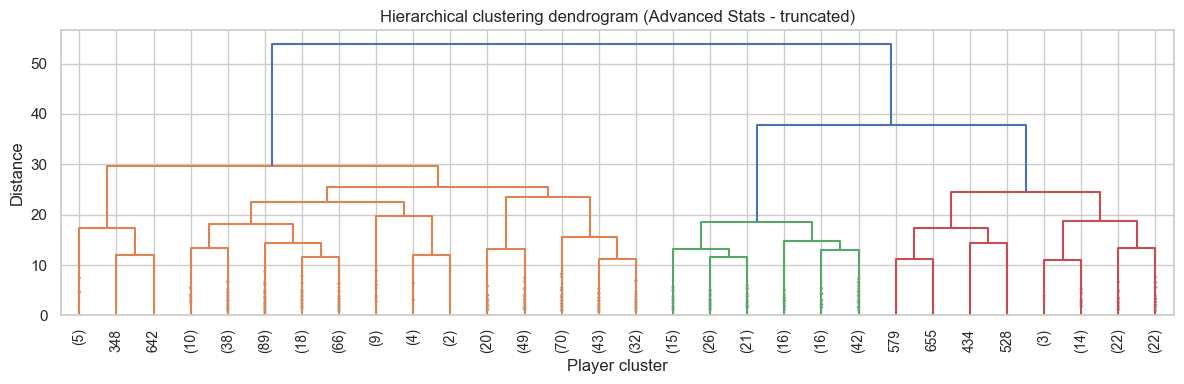

n_clusters=4; unique clusters=4
silhouette score: 0.214
cluster
0    450
1     65
2    136
3      7
Name: count, dtype: int64

Cluster 0 players:
                Player Team Pos
0        Mikal Bridges  NYK  SF
8           OG Anunoby  NYK  PF
10     Christian Braun  DEN  SG
14     Jaden McDaniels  MIN  PF
15       Keegan Murray  SAC  PF
17         Zach LaVine  CHI  SF
18         Zach LaVine  SAC  SG
20  Michael Porter Jr.  DEN  SF
21       Derrick White  BOS  SG
22       Dyson Daniels  ATL  SG

Cluster 0 mean stats:
PER     13.047716
TS%      0.551909
3PAr     0.424854
FTr      0.245853
ORB%     5.671320
DRB%    14.641624
TRB%    10.146447
AST%    14.268782
STL%     1.653807
BLK%     1.882487
TOV%    12.533756
USG%    18.311421
OWS      0.955330
DWS      0.891371
Age     25.847716
Name: 0.0, dtype: float64

Cluster 1 players:
             Player Team Pos
1         Josh Hart  NYK  SG
2   Anthony Edwards  MIN  SG
3      Devin Booker  PHO  SG
4      James Harden  LAC  PG
5     DeMar DeRoza

In [77]:
# Hierarchical Clustering on player_advanced dataset
numeric_cols_adv = [
    'PER', 'TS%', '3PAr', 'FTr', 'ORB%', 'DRB%', 'TRB%',
    'AST%', 'STL%', 'BLK%', 'TOV%', 'USG%', 'OWS', 'DWS', 'Age'
]

df_players_adv = player_advanced[(player_advanced['Player'] != 'League Average') & (player_advanced['Team'] != '2TM')].copy()
X_raw_adv = df_players_adv[numeric_cols_adv]
X_clean_adv = X_raw_adv.fillna(X_raw_adv.median())

scaler_adv = StandardScaler()
X_adv_scaled = scaler_adv.fit_transform(X_clean_adv)

Z_adv = linkage(X_adv_scaled, method='ward')
plt.figure(figsize=(12, 4))
dendrogram(
    Z_adv,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True
)
plt.title('Hierarchical clustering dendrogram (Advanced Stats - truncated)')
plt.xlabel('Player cluster')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

def cluster_players_adv(n_clusters=4):
    model = AgglomerativeClustering(n_clusters=n_clusters)
    labels = model.fit_predict(X_adv_scaled)
    clustered = df_players_adv[['Player', 'Team', 'Pos']].copy()
    clustered['cluster'] = labels
    print(f'n_clusters={n_clusters}; unique clusters={len(np.unique(labels))}')
    if len(np.unique(labels)) > 1:
        print('silhouette score:', round(silhouette_score(X_adv_scaled, labels), 3))
    print(clustered.groupby('cluster').size().rename('count'))
    return clustered

clustered_players_adv = cluster_players_adv(4)
cluster_means_adv = pd.concat([X_clean_adv.reset_index(drop=True), clustered_players_adv['cluster']], axis=1).groupby('cluster').mean()

for cluster in range(4):
    print(f"\nCluster {cluster} players:")
    print(clustered_players_adv[clustered_players_adv['cluster'] == cluster][['Player', 'Team', 'Pos']].head(10))
    print(f"\nCluster {cluster} mean stats:")
    print(cluster_means_adv.loc[cluster])

Hierarchical clustering offers exploratory grouping rather than ground-truth labels. Depending on feature set, clusters can resemble archetypes such as scoring guards, rebounding/rim-protecting bigs, lower-usage role players, and more balanced profiles. Where silhouette scores are modest, separation should be interpreted cautiously.

### K-Means Clustering

cluster
0    145
1    129
2    290
3     94
Name: count, dtype: int64
silhouette score: 0.16

Cluster 0 players:
             Player Team Pos
167      Drew Timme  BRK  PF
233  Nick Smith Jr.  CHO  SG
288  Oshae Brissett  PHI  SF
302    Jared Rhoden  CHO  SG
304   Jaylen Nowell  NOP  SG
323    Caleb Martin  DAL  SF
324   Tyson Etienne  BRK  PG
326      KJ Simpson  CHO  PG
332      AJ Johnson  MIL  SG
333      AJ Johnson  WAS  SG

Cluster 0 mean stats:
PER       6.203448
TS%       0.415119
3PAr      0.460832
FTr       0.242888
ORB%      5.085517
DRB%     13.170345
TRB%      9.142759
AST%     12.162759
STL%      1.650345
BLK%      1.200690
TOV%     15.295833
USG%     16.732414
OWS      -0.138621
DWS       0.157241
WS        0.021379
WS/48    -0.032572
OBPM     -5.824138
DBPM     -1.138621
BPM      -6.959310
VORP     -0.163448
PTS       2.867586
AST       0.943448
TRB       1.637241
STL       0.324828
BLK       0.134483
3P        0.354483
FT        0.395862
Name: 0, dtype: float64

Cluster

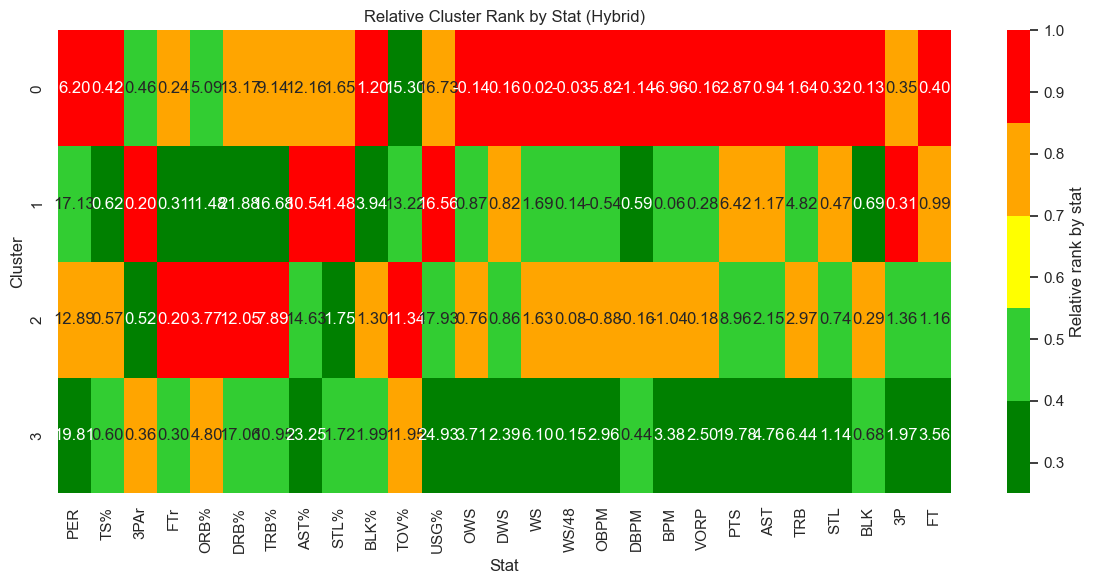

,Player,Team,Pos,cluster,predicted_position
332,AJ Johnson,MIL,SG,0,Guard
333,AJ Johnson,WAS,SG,0,Guard
323,Caleb Martin,DAL,SF,0,Guard
167,Drew Timme,BRK,PF,0,Big
302,Jared Rhoden,CHO,SG,0,Big
304,Jaylen Nowell,NOP,SG,0,Big
326,KJ Simpson,CHO,PG,0,Guard
233,Nick Smith Jr.,CHO,SG,0,Guard
288,Oshae Brissett,PHI,SF,0,Big
324,Tyson Etienne,BRK,PG,0,Guard


In [78]:
# K-means Clustering on player_stats (hybrid) dataset
qualified_players = player_model.copy()
qualified_features = qualified_players[numeric_cols].fillna(qualified_players[numeric_cols].median())
qualified_scaled = scaler.fit_transform(qualified_features)

kmeans_hybrid = KMeans(n_clusters=4, random_state=42, n_init=10)
qualified_players["cluster"] = kmeans_hybrid.fit_predict(qualified_scaled)

print(qualified_players["cluster"].value_counts().sort_index())
print("silhouette score:", round(silhouette_score(qualified_scaled, qualified_players["cluster"]), 3))

cluster_means_hybrid = (
    pd.concat(
        [qualified_players[numeric_cols].reset_index(drop=True), qualified_players["cluster"].reset_index(drop=True)],
        axis=1,
    )
    .groupby("cluster")
    .mean()
)

for cluster in range(4):
    print(f"\nCluster {cluster} players:")
    print(qualified_players[qualified_players['cluster'] == cluster][['Player', 'Team', 'Pos']].head(10))
    print(f"\nCluster {cluster} mean stats:")
    print(cluster_means_hybrid.loc[cluster])

# Display feature importance for KMeans clusters using heatmap
ranked_hybrid = cluster_means_hybrid.rank(axis=0, method="average", ascending=False)
ranked_norm_hybrid = ranked_hybrid / ranked_hybrid.max()

plt.figure(figsize=(12, 6))
rank_colors = ListedColormap(["green", "limegreen", "yellow", "orange", "red"])
sns.heatmap(
    ranked_norm_hybrid,
    annot=cluster_means_hybrid.round(2),
    fmt=".2f",
    cmap=rank_colors,
    cbar_kws={"label": "Relative rank by stat"}
)
plt.title("Relative Cluster Rank by Stat (Hybrid)")
plt.xlabel("Stat")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

top_players_per_cluster = qualified_players.groupby('cluster').head(10)[['Player', 'Team', 'Pos', 'cluster', 'predicted_position']].sort_values(by=['cluster', 'Player'])
top_players_per_cluster

cluster
0     78
1    223
2    259
3     98
Name: count, dtype: int64
silhouette score: 0.308

Cluster 0 players:
              Player Team Pos
18     Anthony Davis  DAL  PF
70       Evan Mobley  CLE  PF
94       Ivica Zubac  LAC   C
102     Myles Turner  IND   C
106    Mark Williams  CHO   C
108    Chet Holmgren  OKC   C
114  P.J. Washington  DAL  PF
119     Jakob Poeltl  TOR   C
120    Deandre Ayton  POR   C
124         Naz Reid  MIN   C

Cluster 0 mean stats:
PTS     9.888462
AST     1.729487
TRB     7.070513
STL     0.725641
BLK     1.039744
3P      0.470513
FT      1.508974
FG      3.960256
MP     23.317949
G      50.064103
Name: 0, dtype: float64

Cluster 1 players:
               Player Team Pos
90    De'Andre Hunter  CLE  SF
96      Malik Beasley  DET  SG
98    Jordan Clarkson  UTA  SG
104  Jonathan Kuminga  GSW  PF
105      Jared McCain  PHI  SG
110        Kyle Kuzma  WAS  PF
111        Kyle Kuzma  MIL  PF
112    Stephon Castle  SAS  SG
113      Aaron Gordon  DEN  PF
116    Qu

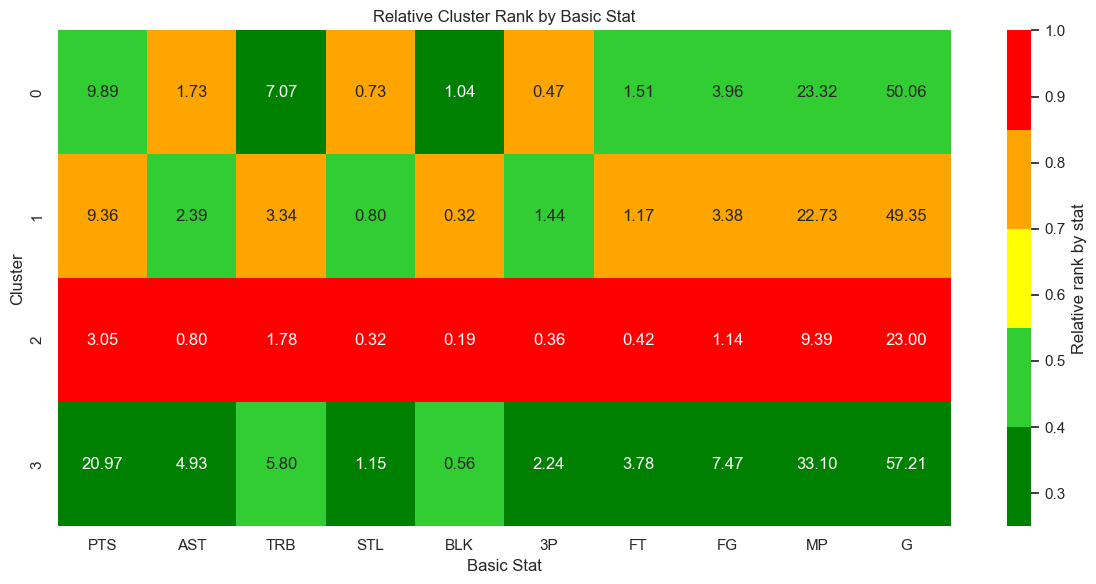

In [79]:
# K-means Clustering on player_basic dataset
qualified_players_basic = player_model_basic.copy()
qualified_features_basic = qualified_players_basic[numeric_cols_basic].fillna(qualified_players_basic[numeric_cols_basic].median())
qualified_scaled_basic = scaler_basic.fit_transform(qualified_features_basic)

kmeans_basic = KMeans(n_clusters=4, random_state=42, n_init=10)
qualified_players_basic["cluster"] = kmeans_basic.fit_predict(qualified_scaled_basic)

print(qualified_players_basic["cluster"].value_counts().sort_index())
print("silhouette score:", round(silhouette_score(qualified_scaled_basic, qualified_players_basic["cluster"]), 3))

cluster_means_basic_kmeans = (
    pd.concat(
        [qualified_players_basic[numeric_cols_basic].reset_index(drop=True), qualified_players_basic["cluster"].reset_index(drop=True)],
        axis=1,
    )
    .groupby("cluster")
    .mean()
)

for cluster in range(4):
    print(f"\nCluster {cluster} players:")
    print(qualified_players_basic[qualified_players_basic['cluster'] == cluster][['Player', 'Team', 'Pos']].head(10))
    print(f"\nCluster {cluster} mean stats:")
    print(cluster_means_basic_kmeans.loc[cluster])

ranked_basic = cluster_means_basic_kmeans.rank(axis=0, method="average", ascending=False)
ranked_norm_basic = ranked_basic / ranked_basic.max()

plt.figure(figsize=(12, 6))
rank_colors = ListedColormap(["green", "limegreen", "yellow", "orange", "red"])
sns.heatmap(
    ranked_norm_basic,
    annot=cluster_means_basic_kmeans.round(2),
    fmt=".2f",
    cmap=rank_colors,
    cbar_kws={"label": "Relative rank by stat"}
)
plt.title("Relative Cluster Rank by Basic Stat")
plt.xlabel("Basic Stat")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

cluster
0    141
1    203
2    105
3    209
Name: count, dtype: int64
silhouette score: 0.1

Cluster 0 players:
                 Player Team Pos
12          Ivica Zubac  LAC   C
37          Rudy Gobert  MIN   C
42        Jarrett Allen  CLE   C
65         Myles Turner  IND   C
90       Onyeka Okongwu  ATL   C
93          Jalen Duren  DET   C
109          Yves Missi  NOP   C
123         Nic Claxton  BRK   C
138     P.J. Washington  DAL  PF
154  Wendell Carter Jr.  ORL   C

Cluster 0 mean stats:
PER     16.736170
TS%      0.601621
3PAr     0.180964
FTr      0.321307
ORB%    11.723404
DRB%    22.712057
TRB%    17.219858
AST%    10.364539
STL%     1.451064
BLK%     3.790780
TOV%    13.807857
USG%    16.854610
OWS      1.088652
DWS      0.962411
Age     25.652482
Name: 0, dtype: float64

Cluster 1 players:
                      Player Team Pos
0              Mikal Bridges  NYK  SF
14           Jaden McDaniels  MIN  PF
15             Keegan Murray  SAC  PF
18               Zach LaVine  SAC  S

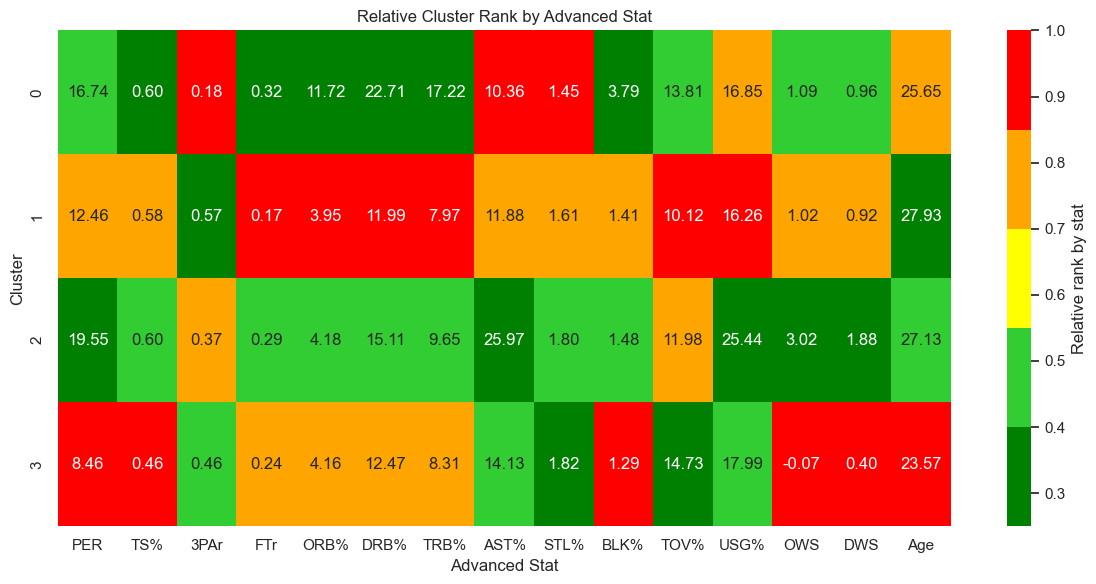

In [80]:
# K-means Clustering on player_advanced dataset
qualified_players_adv = player_model_adv.copy()
qualified_features_adv = qualified_players_adv[numeric_cols_adv].fillna(qualified_players_adv[numeric_cols_adv].median())
qualified_scaled_adv = scaler_adv.fit_transform(qualified_features_adv)

kmeans_adv = KMeans(n_clusters=4, random_state=42, n_init=10)
qualified_players_adv["cluster"] = kmeans_adv.fit_predict(qualified_scaled_adv)

print(qualified_players_adv["cluster"].value_counts().sort_index())
print("silhouette score:", round(silhouette_score(qualified_scaled_adv, qualified_players_adv["cluster"]), 3))

cluster_means_adv_kmeans = (
    pd.concat(
        [qualified_players_adv[numeric_cols_adv].reset_index(drop=True), qualified_players_adv["cluster"].reset_index(drop=True)],
        axis=1,
    )
    .groupby("cluster")
    .mean()
)

for cluster in range(4):
    print(f"\nCluster {cluster} players:")
    print(qualified_players_adv[qualified_players_adv['cluster'] == cluster][['Player', 'Team', 'Pos']].head(10))
    print(f"\nCluster {cluster} mean stats:")
    print(cluster_means_adv_kmeans.loc[cluster])

ranked_adv = cluster_means_adv_kmeans.rank(axis=0, method="average", ascending=False)
ranked_norm_adv = ranked_adv / ranked_adv.max()

plt.figure(figsize=(12, 6))
rank_colors = ListedColormap(["green", "limegreen", "yellow", "orange", "red"])
sns.heatmap(
    ranked_norm_adv,
    annot=cluster_means_adv_kmeans.round(2),
    fmt=".2f",
    cmap=rank_colors,
    cbar_kws={"label": "Relative rank by stat"}
)
plt.title("Relative Cluster Rank by Advanced Stat")
plt.xlabel("Advanced Stat")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

Clustering summary: these unsupervised groupings complement classification by revealing statistical archetypes without pre-defined labels. They are useful for pattern discovery, but cluster boundaries are not definitive and should be interpreted as approximate profile groupings.

## Final Conclusions

This project examined how NBA season statistics relate to scoring, efficiency, and role structure. The main goals were to model `PTS` and `PER`, classify broad role groups, and explore player archetypes through clustering.

Key findings:
- Regression: `PTS` is highly predictable when direct scoring ingredients are included; after removing those, performance remains strong with better interpretability. Lasso provides useful coefficient shrinkage and feature selection.
- PER modeling: basic box-score features can estimate `PER` reasonably, and selective non-linear terms improve fit while increasing model complexity.
- Classification: logistic models distinguish broad guard-vs-big role tendencies, especially with advanced/hybrid metrics, but wing/hybrid players remain expected boundary cases.
- Clustering: hierarchical and K-means analyses reveal practical archetypes (e.g., high-usage scorers, rebounding/rim-oriented bigs, lower-usage role profiles), though separation quality is not perfect.

Limitations and takeaway:
- Models are based on season aggregates and simplified role definitions, so interpretation should remain descriptive rather than causal.
- Statistical profiles capture meaningful tendencies, but official basketball roles are not always cleanly separable from box-score data alone.

Overall, the combined workflow shows that scoring and efficiency can be modeled effectively, role tendencies can be classified with moderate-to-strong performance, and unsupervised clustering adds useful context for understanding player archetypes.